In [1]:
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scr.qsvdd_core.data_loader import QuantumDataLoader
import numpy as np
from scr.qsvdd_core.model import circuit_training

## Constantes

In [2]:
dataset = 'fraud'
ntrain = 0 ; latent_dim = 3
num_params_conv = 45
cost_func = 'svdd'
steps = 500
learning_rate = 0.001
batch_size = 16

## dataset

In [3]:
print("Diretório atual:", os.getcwd())
print("Arquivos nesta pasta:", os.listdir())

Diretório atual: D:\projects\QSVDD2\notebooks
Arquivos nesta pasta: ['circuit_visualization.ipynb', 'data_visualization.ipynb']


In [4]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset carregado com sucesso!\n")
print("First 5 records:\n", df.head())

Dataset carregado com sucesso!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


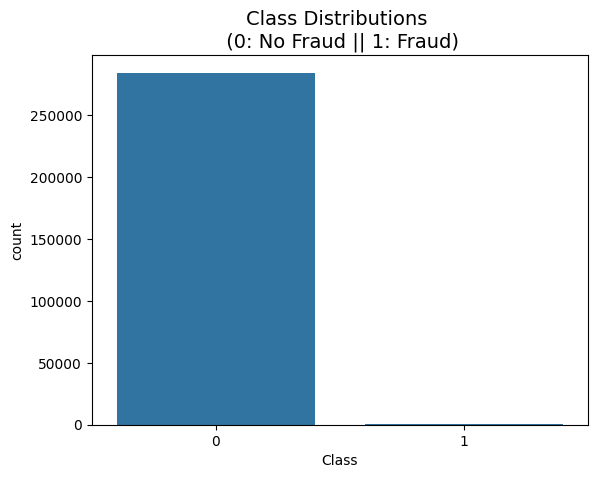

In [7]:
plt.style.use('default')

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

plt.show()

In [8]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']

In [9]:
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [10]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [11]:
loader = QuantumDataLoader()

X_quantum, y = loader.prepare_fraud_data(df)

print(f"Features para o circuito: {X_quantum.shape}") # Deve mostrar (n_linhas, 32)
print(f"Labels: {y.shape}")

Features para o circuito: (284807, 32)
Labels: (284807,)


In [12]:
"""
One-class Training:
Separação em exemplos normais e fraudulentos
O QSVDD irá aprender o que é normal.
"""
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]


# Treino
# coleta 1000 exemplos normais para o treino
X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train_normal = X_quantum[X_train_normal_indices]
y_train_normal = y[X_train_normal_indices]

# X_train contém apenas transações legítimas
X_train = X_train_normal
Y_train = y_train_normal

# Teste (balanceado)
# O código retira 100 exemplos normais que não foram usados no treino
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_normal = X_quantum[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

# O código retira 100 exemplos de fraudes.
X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)
X_test_abnormal = X_quantum[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# cria um conjunto de teste com 200 exemplos (50% normal, 50% fraude)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)


center = np.zeros(latent_dim)
center_train = np.tile(center, (len(X_train), 1))


print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test_normal shape: {X_test_normal.shape}')
print(f'X_test_abnormal shape: {X_test_abnormal.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')
print(f'center_train shape: {center_train.shape}')

X_train shape: (1000, 32)
Y_train shape: (1000,)
X_test_normal shape: (100, 32)
X_test_abnormal shape: (100, 32)
X_test shape: (200, 32)
Y_test shape: (200,)
center_train shape: (1000, 3)


## Treinamento

In [13]:
train_Xdata = X_train
train_Ydata = center_train
loss_history, est_params, param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     n_params=num_params_conv,
                     )
)

iteration: 0 | cost: 0.020858
iteration: 1 | cost: 0.019303
iteration: 2 | cost: 0.018506
iteration: 3 | cost: 0.019302
iteration: 4 | cost: 0.018296
iteration: 5 | cost: 0.018000
iteration: 6 | cost: 0.018557
iteration: 7 | cost: 0.016006
iteration: 8 | cost: 0.017714
iteration: 9 | cost: 0.016733
iteration: 10 | cost: 0.016761
iteration: 11 | cost: 0.015659
iteration: 12 | cost: 0.015581
iteration: 13 | cost: 0.015447
iteration: 14 | cost: 0.015525
iteration: 15 | cost: 0.016576
iteration: 16 | cost: 0.015319
iteration: 17 | cost: 0.014779
iteration: 18 | cost: 0.015873
iteration: 19 | cost: 0.014787
iteration: 20 | cost: 0.014869
iteration: 21 | cost: 0.014267
iteration: 22 | cost: 0.013901
iteration: 23 | cost: 0.013253
iteration: 24 | cost: 0.013059
iteration: 25 | cost: 0.012515
iteration: 26 | cost: 0.013914
iteration: 27 | cost: 0.013237
iteration: 28 | cost: 0.012854
iteration: 29 | cost: 0.013247
iteration: 30 | cost: 0.011820
iteration: 31 | cost: 0.012471
iteration: 32 | co

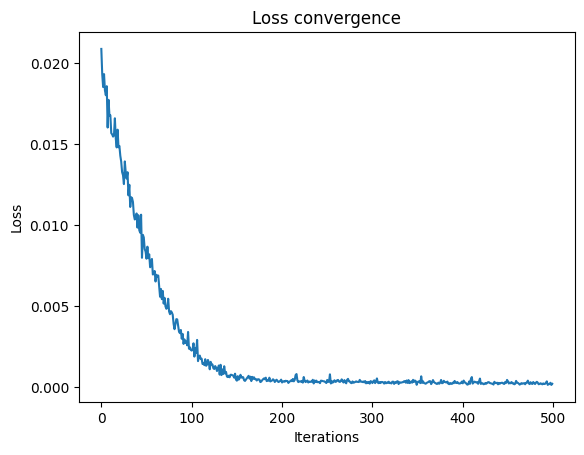

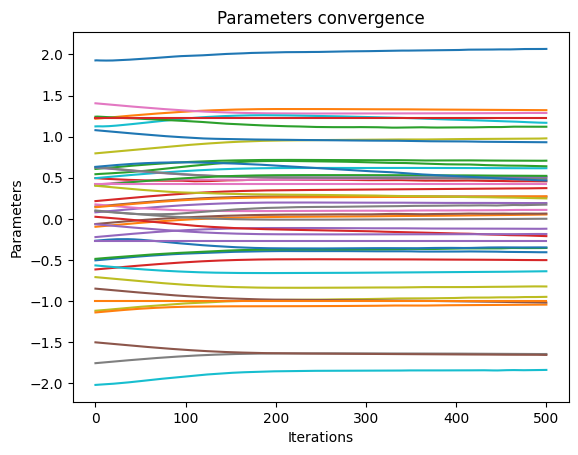

In [14]:
plt.style.use('default')
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss convergence")
plt.show()

plt.plot(param_history)
plt.xlabel("Iterations")
plt.ylabel("Parameters")
plt.title("Parameters convergence")
plt.show()

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

def radius(data, center):
    res = []

    res.append(abs(data - center)**2)
    return res

In [17]:
import time
import numpy as np
import random
from sklearn.metrics import roc_curve, roc_auc_score
from scr.qsvdd_core.engine import  QuantumEngine

trained_params = est_params
y_true = []
y_pred = []

def test(ntrain, latent_dim):
    start_time = time.time()
    y_true.clear()
    y_pred.clear()

    for i in range(2):
        step_start_time = time.time()

        # Filtra os dados da classe i no seu dataset de teste
        filter_idx = np.where(Y_test == i)[0] # Garante que pega os índices corretamente
        test_data = X_test[filter_idx]

        label = 0 if i == ntrain else 1
        print(f"Processing class {i} (label {label}) | Samples: {len(test_data)}")

        # Execução das predições usando a Engine
        # Nota: dependendo do tamanho de test_data, isso pode demorar.
        pred = np.asarray([engine.quantum_circuit(x, trained_params) for x in test_data])

        # Cálculo da distância para o centro (Lógica QSVDD)
        for j in range(len(pred)):
            # Garanta que center_train seja um array com o mesmo shape de pred[j]
            diff = pred[j] - center_train
            dist = np.mean(diff**2)

            y_pred.append(dist)
            y_true.append(label)

        step_end_time = time.time()
        print(f"Finished class {i} in {step_end_time - step_start_time:.2f}s")

    # Cálculo das métricas finais
    auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)

    end_time = time.time()
    print(f"Test completed in {end_time - start_time:.2f}s | AUC: {auc:.4f}")

    return auc, y_pred, y_true, fpr, tpr # Removido o return duplicado

auc, y_pred, y_true, fpr, tpr = test(ntrain, latent_dim)
print("Test completed")

Processing class 0 (label 0)


NameError: name 'engine' is not defined